# 🏆 Football Score Prediction — AW-MAE Competition Pipeline

## 0. Setup & Import

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import seaborn as sns

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except Exception:
    HAS_CAT = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
np.random.seed(42)

print('Libraries loaded ✅')

Libraries loaded ✅
XGBoost available : True
CatBoost available: True


## 1. AW-MAE Metric

In [57]:
def get_tournament_weight(tournament: str) -> float:
    t = tournament.lower()
    major = ['world cup','copa america','copa américa','uefa euro',
             'african cup of nations','afc asian cup','gold cup','olympic','nations cup']
    for kw in major:
        if kw in t and 'qualif' not in t:
            return 1.5
    if 'qualif' in t or 'qualification' in t:
        return 1.0
    if 'friendly' in t:
        return 0.8
    return 1.2


def awmae_score(ytg, yog, ptg, pog, w, l1=0.10, l2=0.05, l3=0.05):
    ytg, yog = np.array(ytg), np.array(yog)
    ptg = np.round(np.array(ptg)).clip(0)
    pog = np.round(np.array(pog)).clip(0)
    w   = np.array(w)
    mae = (np.abs(ytg - ptg) + np.abs(yog - pog)) / 2
    exact   = ((ptg == ytg) & (pog == yog)).astype(float)
    outcome = (np.sign(ytg - yog) == np.sign(ptg - pog)).astype(float)
    gd_b    = ((ytg - yog) == (ptg - pog)).astype(float)
    loss    = mae - (l1 * exact + l2 * outcome + l3 * gd_b)
    return np.sum(w * loss) / np.sum(w)

print('AW-MAE (perfect):', awmae_score([2,1],[1,0],[2,1],[1,0],[1.5,1.0]))
print('AW-MAE (zeros):  ', awmae_score([2,1],[1,0],[0,0],[0,0],[1.5,1.0]))

AW-MAE (perfect): -0.2
AW-MAE (zeros):   1.1


## 2. Load & EDA

In [58]:
train = pd.read_csv('./dataset/train.csv')
test  = pd.read_csv('./dataset/test.csv')
sub   = pd.read_csv('./dataset/sample submission.csv')

print(f'Train: {train.shape}  ({train["date"].min()} → {train["date"].max()})')
print(f'Test:  {test.shape}  ({test["date"].min()} → {test["date"].max()})')
print(f'Targets: team_goals mean={train["team_goals"].mean():.2f}, opp_goals mean={train["opp_goals"].mean():.2f}')

Train: (78772, 47)  (1872-11-30 → 2011-08-04)
Test:  (42422, 20)  (2011-08-06 → 2026-03-31)
Targets: team_goals mean=1.56, opp_goals mean=1.56


In [59]:
train.head()

,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,0,0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0.0,0.0,NaN,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,4,2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,98.0,98.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M000002_Scotland,M000002,1873-03-08,M,Scotland,England,0,0,Friendly,England,2,4,1.0,4.0,-3.0,0.0,2.0,-2.0,1.0,0.0,98.0,0.0,1.0,4.0,0.0,0.0,2.0,1.0,0.0,0.5,1484.0,1516.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M000003_Scotland,M000003,1874-03-07,M,Scotland,England,1,0,Friendly,Scotland,2,1,1.0,4.0,-3.0,-2.0,2.0,-4.0,1.0,-2.0,364.0,364.0,1.0,4.0,1.0,2.0,2.0,1.0,0.0,0.5,1484.0,1516.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
train.describe()

,is_home,neutral,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
count,78772.000000,78772.000000,78772.000000,78772.000000,78478.000000,78596.000000,78332.000000,78478.000000,78596.000000,78332.000000,66796.000000,66796.00000,78478.000000,78596.000000,78478.000000,78596.000000,78478.000000,78478.000000,78596.000000,78596.000000,78478.000000,78596.000000,78772.000000,78772.000000,36826.000000,36826.000000,34870.000000,78772.000000,78772.000000,6.390000e+04,6.390000e+04,52815.000000,52815.000000,58218.000000,48380.000000,48380.000000,61698.000000
mean,0.500000,0.269030,1.563119,1.563119,6.922806,7.083617,-0.162858,0.038087,0.348771,-0.307512,5.504881,0.00000,71.714404,34.818566,13.738589,13.894893,1.565813,1.569871,1.598451,1.538018,0.391819,0.397284,1569.420951,1572.593109,73.402922,73.402922,0.000000,0.532499,0.532499,3.253328e+07,3.253328e+07,9854.331528,9854.331528,158.222062,1938.851671,1938.851671,18.180117
std,0.500003,0.443458,1.792137,1.792137,3.628003,3.632253,5.064980,8.051035,8.041305,11.218990,4.079551,7.44914,380.195616,239.401382,5.963349,5.964928,0.986647,1.124614,0.998775,1.106115,0.204645,0.205047,156.758263,156.520136,51.025529,51.025529,52.307246,0.498946,0.498946,8.332939e+07,8.332939e+07,15493.540286,15493.540286,1240.901854,3021.255139,3021.255139,7.802716
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-15.000000,-75.000000,-75.000000,-105.000000,0.000000,-55.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1009.550658,1009.550658,1.000000,1.000000,-200.000000,0.000000,0.000000,5.960000e+02,5.960000e+02,12.802812,12.802812,-9999.000000,0.000000,0.000000,-20.497587
25%,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,-4.000000,-4.000000,-4.000000,-6.000000,2.000000,-4.00000,3.000000,0.000000,10.000000,10.000000,0.800000,0.800000,1.000000,0.800000,0.200000,0.285714,1463.840900,1467.529150,30.000000,30.000000,-32.000000,0.000000,0.000000,3.543776e+06,3.543776e+06,735.981909,735.981909,45.000000,0.000000,0.000000,12.501454
50%,0.500000,0.000000,1.000000,1.000000,7.000000,7.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.00000,14.000000,0.000000,14.000000,14.000000,1.400000,1.400000,1.400000,1.400000,0.400000,0.400000,1567.040996,1571.021264,65.000000,65.000000,0.000000,1.000000,1.000000,9.820481e+06,9.820481e+06,2818.913920,2818.913920,117.000000,599.634551,599.634551,19.680511
75%,1.000000,1.000000,2.000000,2.000000,10.000000,10.000000,3.000000,5.000000,5.000000,6.000000,9.000000,4.00000,45.000000,13.000000,18.000000,18.000000,2.000000,2.000000,2.000000,2.000000,0.500000,0.500000,1673.779427,1676.561310,109.000000,109.000000,32.000000,1.000000,1.000000,3.077462e+07,3.077462e+07,12126.939199,12126.939199,320.000000,2509.508681,2509.508681,24.441889
max,1.000000,1.000000,31.000000,31.000000,15.000000,15.000000,15.000000,68.000000,65.000000,89.000000,15.000000,55.00000,31872.000000,18605.000000,30.000000,30.000000,17.000000,24.000000,13.600000,21.000000,1.000000,1.000000,2096.773012,2096.512684,205.000000,205.000000,200.000000,1.000000,1.000000,1.240614e+09,1.240614e+09,185785.725925,185785.725925,1877.500000,19783.072925,19783.072925,38.179592


In [61]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78772 entries, 0 to 78771
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          78772 non-null  object 
 1   match_id                    78772 non-null  object 
 2   date                        78772 non-null  object 
 3   gender                      78772 non-null  object 
 4   team                        78772 non-null  object 
 5   opponent                    78772 non-null  object 
 6   is_home                     78772 non-null  int64  
 7   neutral                     78772 non-null  int64  
 8   tournament                  78772 non-null  object 
 9   venue_country               78772 non-null  object 
 10  team_goals                  78772 non-null  int64  
 11  opp_goals                   78772 non-null  int64  
 12  team_points_last5           78478 non-null  float64
 13  opp_points_last5            785

In [62]:
train.isna().sum()

Id                                0
match_id                          0
date                              0
gender                            0
team                              0
opponent                          0
is_home                           0
neutral                           0
tournament                        0
venue_country                     0
team_goals                        0
opp_goals                         0
team_points_last5               294
opp_points_last5                176
points_last5_diff               440
team_gd_last5                   294
opp_gd_last5                    176
gd_last5_diff                   440
h2h_points_last5              11976
h2h_gd_last5                  11976
days_since_last_match_team      294
days_since_last_match_opp       176
team_points_last10              294
opp_points_last10               176
team_avg_goals_last5            294
team_avg_conceded_last5         294
opp_avg_goals_last5             176
opp_avg_conceded_last5      

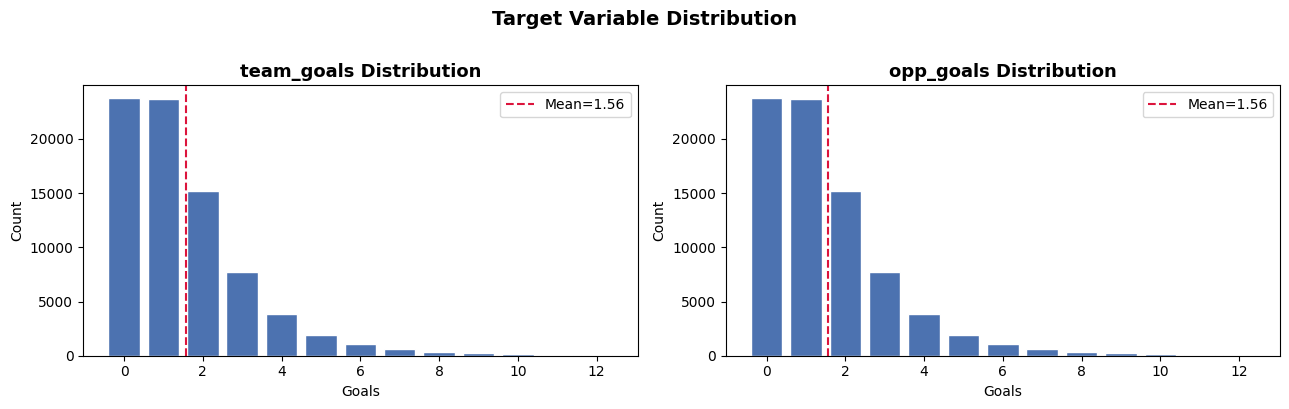

In [63]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['team_goals', 'opp_goals']):
    counts = train[col].value_counts().sort_index()
    ax.bar(counts.index[:13], counts.values[:13], color='#4C72B0', edgecolor='white')
    ax.axvline(train[col].mean(), color='crimson', linestyle='--', label=f'Mean={train[col].mean():.2f}')
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count'); ax.legend()
plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [64]:
train['tournament_weight'] = train['tournament'].apply(get_tournament_weight)
test['tournament_weight']  = test['tournament'].apply(get_tournament_weight)

print('Avg goals per tournament weight:')
print(train.groupby('tournament_weight')[['team_goals','opp_goals']].mean().round(3))
print('\nWeight distribution:',dict(train['tournament_weight'].value_counts()))

Avg goals per tournament weight:
                   team_goals  opp_goals
tournament_weight                       
0.8                     1.488      1.488
1.0                     1.538      1.538
1.2                     1.704      1.704
1.5                     1.556      1.556

Weight distribution: {0.8: np.int64(28006), 1.0: np.int64(24178), 1.2: np.int64(19510), 1.5: np.int64(7078)}


In [65]:
train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

for df in [train, test]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['decade'] = (df['year'] // 10) * 10
    df['total_goals'] = df['team_goals'] + df['opp_goals'] if 'team_goals' in df.columns else np.nan
    df['goal_diff'] = df['team_goals'] - df['opp_goals'] if 'team_goals' in df.columns else np.nan

def get_outcome(row):
    if row['team_goals'] > row['opp_goals']:
        return 'Win'
    elif row['team_goals'] < row['opp_goals']:
        return 'Loss'
    return 'Draw'

train['outcome'] = train.apply(get_outcome, axis=1)

print('Train shape :', train.shape)
print('Test shape  :', test.shape)
print('Train date range:', train['date'].min().date(), '→', train['date'].max().date())
print('Test date range :', test['date'].min().date(), '→', test['date'].max().date())
print('\nJumlah match_id unik di train:', train['match_id'].nunique())
print('Distribusi jumlah baris per match_id:')
print(train.groupby('match_id').size().value_counts().sort_index())

Train shape : (78772, 54)
Test shape  : (42422, 26)
Train date range: 1872-11-30 → 2011-08-04
Test date range : 2011-08-06 → 2026-03-31

Jumlah match_id unik di train: 39386
Distribusi jumlah baris per match_id:
2    39386
Name: count, dtype: int64


Top 20 kolom dengan missing value terbesar:


,missing_count,missing_pct,dtype
rank_diff,43902,55.73,float64
rank_team,41946,53.25,float64
rank_opponent,41946,53.25,float64
distance_travel_team,30392,38.58,float64
distance_travel_opp,30392,38.58,float64
gdp_per_capita_team,25957,32.95,float64
gdp_per_capita_opp,25957,32.95,float64
altitude_venue,20554,26.09,float64
temperature_venue,17074,21.68,float64
population_team,14872,18.88,float64


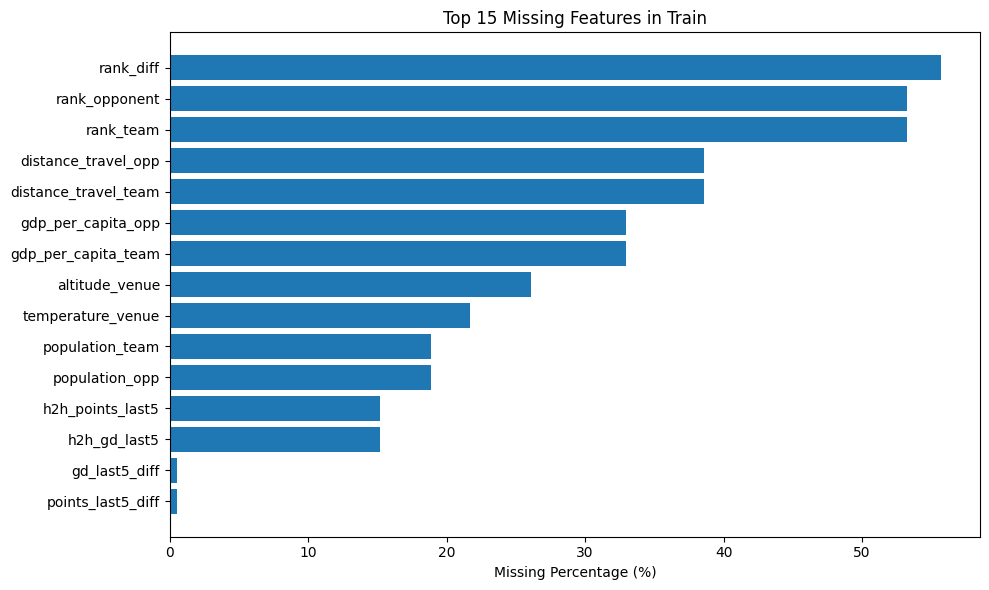

In [66]:
missing_summary = pd.DataFrame({
    'missing_count': train.isna().sum(),
    'missing_pct': (train.isna().mean() * 100).round(2),
    'dtype': train.dtypes.astype(str)
}).sort_values(['missing_pct', 'missing_count'], ascending=False)

print('Top 20 kolom dengan missing value terbesar:')
display(missing_summary.head(20))

plt.figure(figsize=(10, 6))
top_missing = missing_summary[missing_summary['missing_count'] > 0].head(15).sort_values('missing_pct')
plt.barh(top_missing.index, top_missing['missing_pct'])
plt.xlabel('Missing Percentage (%)')
plt.title('Top 15 Missing Features in Train')
plt.tight_layout()
plt.show()

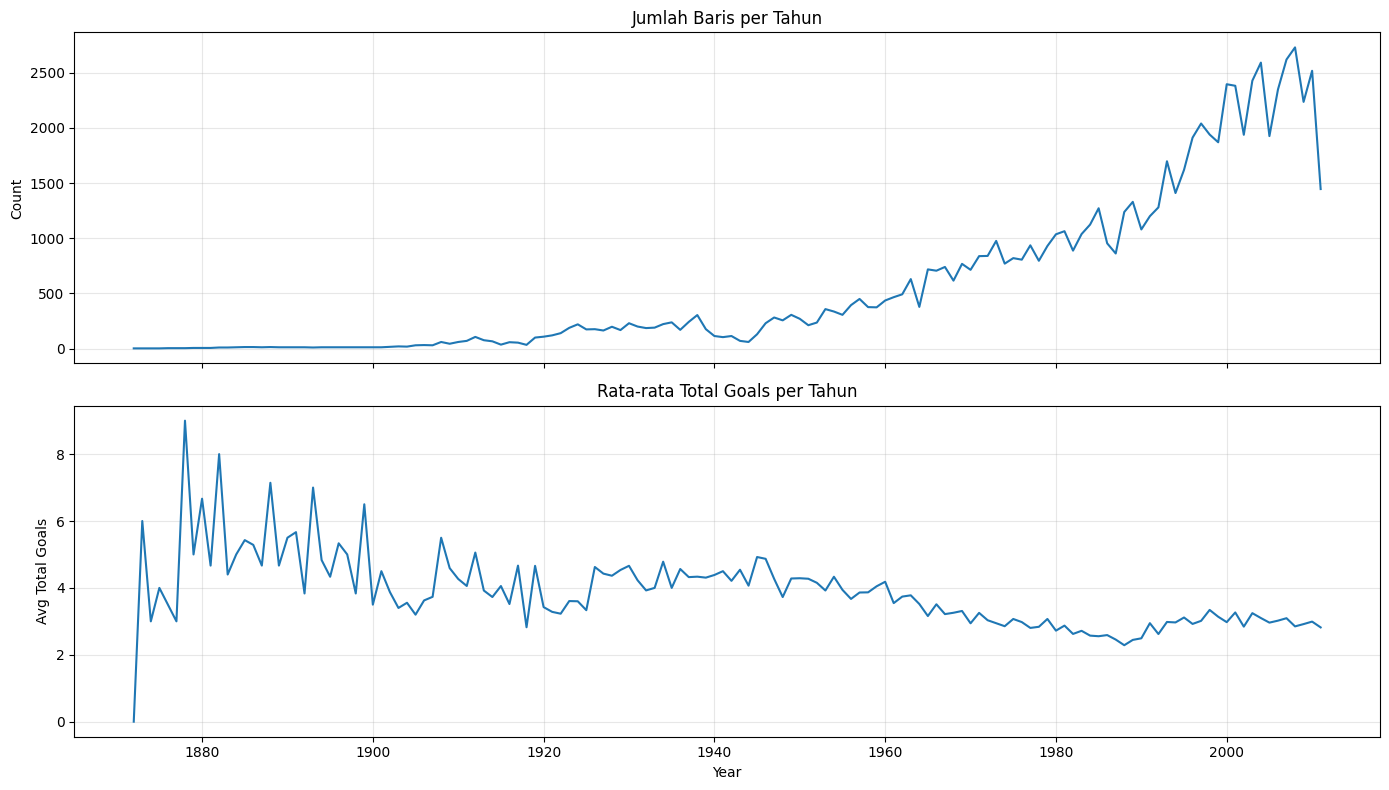

Distribusi data per dekade:


,count
decade,
1870,26
1880,110
1890,118
1900,274
1910,660
1920,1656
1930,2158
1940,1666
1950,3312


In [67]:
yearly_matches = train.groupby('year').size()
yearly_avg_goals = train.groupby('year')['total_goals'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(yearly_matches.index, yearly_matches.values)
axes[0].set_title('Jumlah Baris per Tahun')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].plot(yearly_avg_goals.index, yearly_avg_goals.values)
axes[1].set_title('Rata-rata Total Goals per Tahun')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Total Goals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Distribusi data per dekade:')
display(train['decade'].value_counts().sort_index().to_frame('count'))

Rata-rata goal berdasarkan gender:


team_goals               opp_goals               total_goals         \
             mean median  count      mean median  count        mean median   
gender                                                                       
M           1.511    1.0  69966     1.511    1.0  69966       3.023    3.0   
W           1.975    1.0   8806     1.975    1.0   8806       3.949    3.0   

               
        count  
gender         
M       69966  
W        8806

Rata-rata goal berdasarkan neutral:


,team_goals,opp_goals,total_goals
neutral,,,
0,1.528,1.528,3.056
1,1.658,1.658,3.316


Rata-rata goal berdasarkan is_home:


,team_goals,opp_goals,total_goals
is_home,,,
0,1.238,1.889,3.126
1,1.889,1.238,3.126


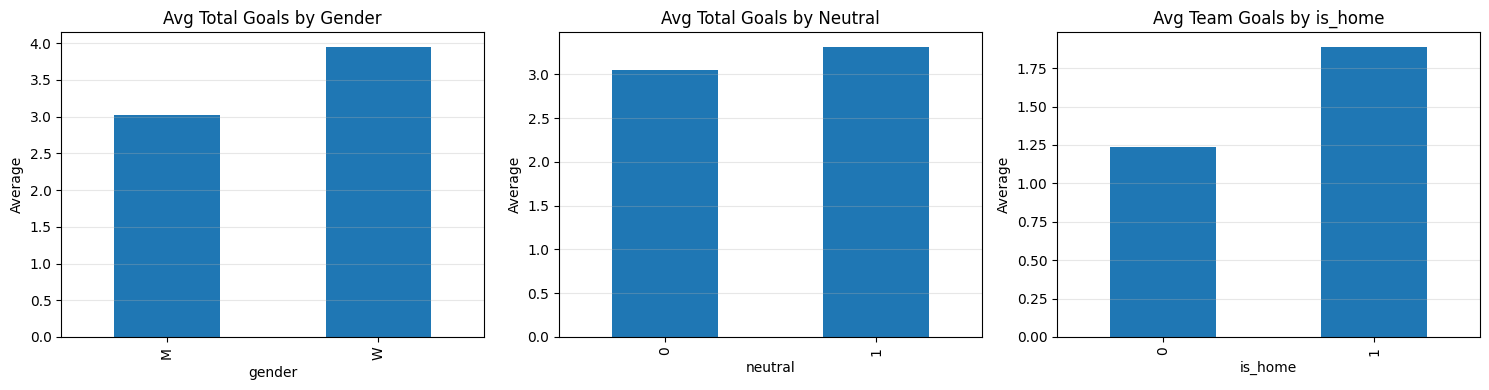

In [68]:
summary_gender = train.groupby('gender')[['team_goals', 'opp_goals', 'total_goals']].agg(['mean', 'median', 'count']).round(3)
summary_neutral = train.groupby('neutral')[['team_goals', 'opp_goals', 'total_goals']].mean().round(3)
summary_home = train.groupby('is_home')[['team_goals', 'opp_goals', 'total_goals']].mean().round(3)

print('Rata-rata goal berdasarkan gender:')
display(summary_gender)

print('Rata-rata goal berdasarkan neutral:')
display(summary_neutral)

print('Rata-rata goal berdasarkan is_home:')
display(summary_home)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train.groupby('gender')['total_goals'].mean().plot(kind='bar', ax=axes[0], title='Avg Total Goals by Gender')
train.groupby('neutral')['total_goals'].mean().plot(kind='bar', ax=axes[1], title='Avg Total Goals by Neutral')
train.groupby('is_home')['team_goals'].mean().plot(kind='bar', ax=axes[2], title='Avg Team Goals by is_home')

for ax in axes:
    ax.set_ylabel('Average')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

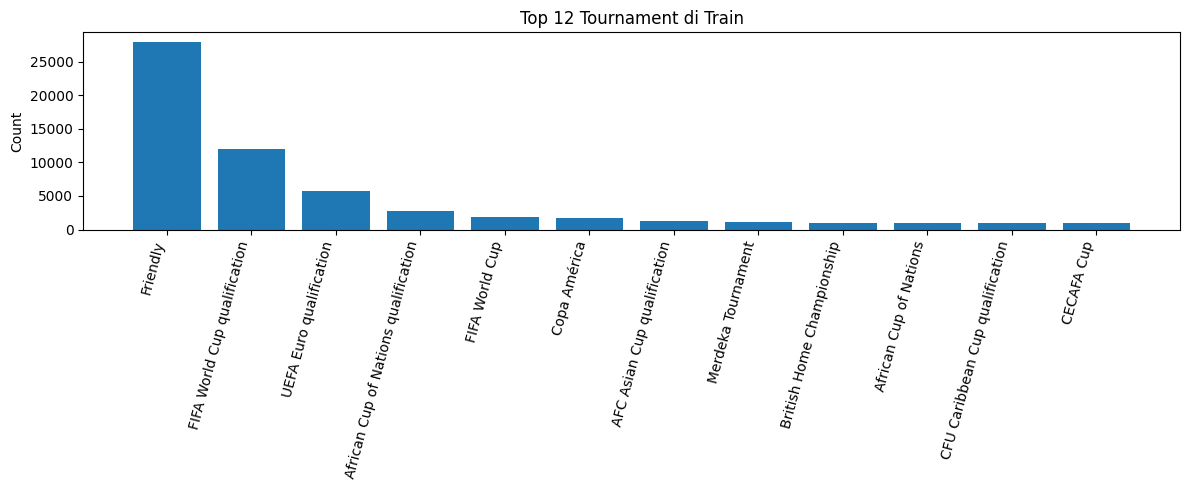

Tournament dengan rata-rata total goal tertinggi (min 100 baris):


,team_goals,opp_goals,total_goals
tournament,,,
Friendly,1.488,1.488,2.976
FIFA World Cup qualification,1.513,1.513,3.027
UEFA Euro qualification,1.537,1.537,3.074
African Cup of Nations qualification,1.234,1.234,2.468
FIFA World Cup,1.488,1.488,2.976
Copa América,1.743,1.743,3.486
AFC Asian Cup qualification,1.773,1.773,3.546
Merdeka Tournament,1.643,1.643,3.286
British Home Championship,1.758,1.758,3.516


In [69]:
top_tournaments = train['tournament'].value_counts().head(12)

plt.figure(figsize=(12, 5))
plt.bar(top_tournaments.index, top_tournaments.values)
plt.xticks(rotation=75, ha='right')
plt.ylabel('Count')
plt.title('Top 12 Tournament di Train')
plt.tight_layout()
plt.show()

tournament_goal_summary = (
    train.groupby('tournament')[['team_goals', 'opp_goals', 'total_goals']]
    .mean()
    .sort_values('total_goals', ascending=False)
    .round(3)
)

print('Tournament dengan rata-rata total goal tertinggi (min 100 baris):')
tour_count = train['tournament'].value_counts()
valid_tour = tour_count[tour_count >= 100].index
display(tournament_goal_summary.loc[valid_tour].head(15))

In [70]:
cat_cols = ['gender', 'team', 'opponent', 'tournament', 'venue_country',
            'confederation_team', 'confederation_opp']

coverage_rows = []
for col in cat_cols:
    train_vals = set(train[col].dropna().unique())
    test_vals  = set(test[col].dropna().unique())
    unseen_in_test = sorted(list(test_vals - train_vals))
    
    coverage_rows.append({
        'column': col,
        'train_unique': len(train_vals),
        'test_unique': len(test_vals),
        'unseen_in_test_count': len(unseen_in_test),
        'sample_unseen_in_test': unseen_in_test[:10]
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

,column,train_unique,test_unique,unseen_in_test_count,sample_unseen_in_test
0,gender,2,2,0,[]
1,team,294,315,50,"[Abkhazia, Artsakh, Aymara, Barawa, Biafra, Ca..."
2,opponent,294,315,50,"[Abkhazia, Artsakh, Aymara, Barawa, Biafra, Ca..."
3,tournament,186,167,87,"[AFF Women's Cup, ASEAN Championship, ASEAN Ch..."
4,venue_country,268,227,7,"[American Samoa, Bonaire, Curacao, Kosovo, Sai..."
5,confederation_team,7,7,0,[]
6,confederation_opp,7,7,0,[]


In [71]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

corr_team = train[numeric_cols].corr()['team_goals'].sort_values(ascending=False)
corr_opp  = train[numeric_cols].corr()['opp_goals'].sort_values(ascending=False)

print('Top 15 korelasi ke team_goals:')
display(corr_team.drop('team_goals', errors='ignore').head(15).to_frame('corr_team_goals'))

print('Top 15 korelasi ke opp_goals:')
display(corr_opp.drop('opp_goals', errors='ignore').head(15).to_frame('corr_opp_goals'))

Top 15 korelasi ke team_goals:


,corr_team_goals
goal_diff,0.772893
total_goals,0.634536
opp_avg_conceded_last5,0.428901
rank_diff,0.365901
gd_last5_diff,0.361488
h2h_gd_last5,0.333771
points_last5_diff,0.300410
rank_opponent,0.237578
h2h_points_last5,0.229930
team_avg_goals_last5,0.185359


Top 15 korelasi ke opp_goals:


,corr_opp_goals
total_goals,0.634536
opp_avg_goals_last5,0.401490
team_avg_conceded_last5,0.317644
opp_gd_last5,0.309233
opp_points_last5,0.247611
rank_team,0.237578
opp_win_rate_last10,0.235435
opp_points_last10,0.215512
elo_opponent,0.165765
distance_travel_team,0.072980


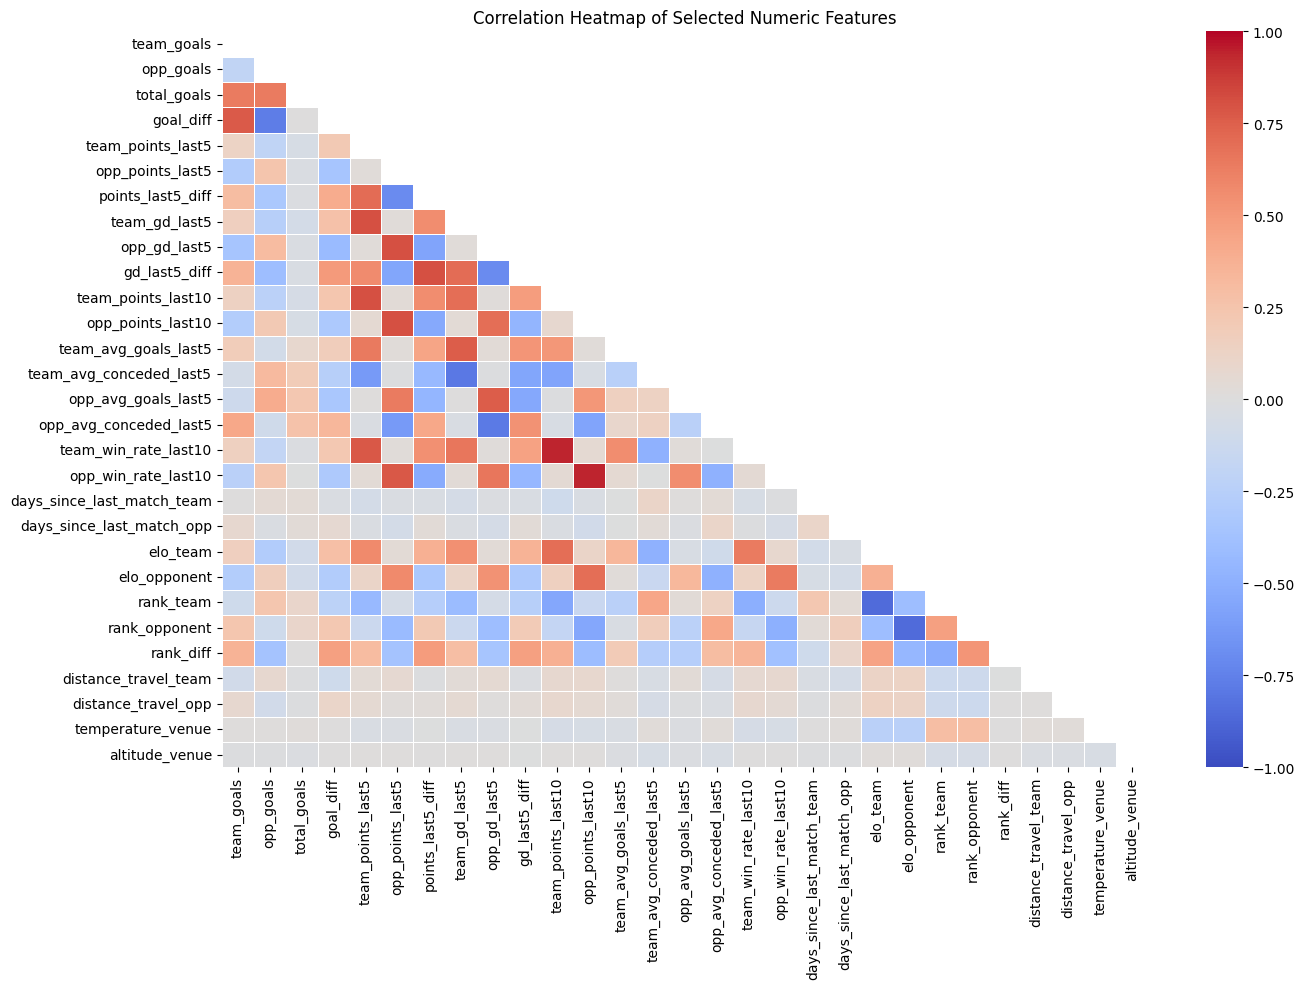

In [72]:
heatmap_cols = [
    'team_goals', 'opp_goals', 'total_goals', 'goal_diff',
    'team_points_last5', 'opp_points_last5', 'points_last5_diff',
    'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff',
    'team_points_last10', 'opp_points_last10',
    'team_avg_goals_last5', 'team_avg_conceded_last5',
    'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'team_win_rate_last10', 'opp_win_rate_last10',
    'days_since_last_match_team', 'days_since_last_match_opp',
    'elo_team', 'elo_opponent',
    'rank_team', 'rank_opponent', 'rank_diff',
    'distance_travel_team', 'distance_travel_opp',
    'temperature_venue', 'altitude_venue'
]

heatmap_cols = [c for c in heatmap_cols if c in train.columns]

corr_mat = train[heatmap_cols].corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_mat,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Selected Numeric Features')
plt.tight_layout()
plt.show()

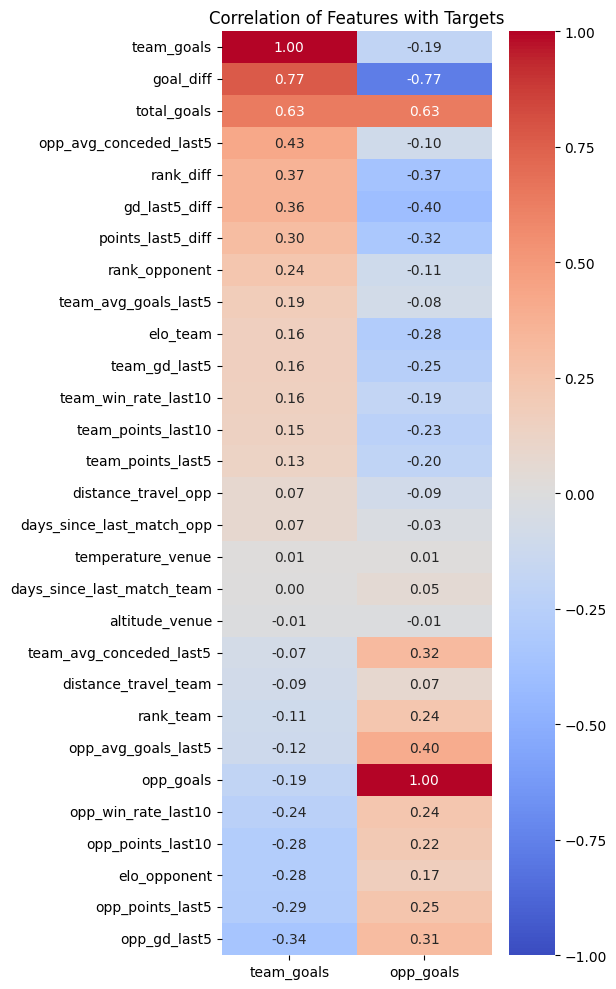

In [73]:
target_corr = train[heatmap_cols].corr()[['team_goals', 'opp_goals']].sort_values(
    by='team_goals', ascending=False
)

plt.figure(figsize=(6, 10))
sns.heatmap(
    target_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)
plt.title('Correlation of Features with Targets')
plt.tight_layout()
plt.show()

In [74]:
print('Statistik deskriptif target:')
display(train[['team_goals', 'opp_goals', 'total_goals', 'goal_diff']].describe())

print('Jumlah baris dengan goal sangat tinggi (>=10):')
high_goal_rows = train[(train['team_goals'] >= 10) | (train['opp_goals'] >= 10)]
print(high_goal_rows.shape[0])

if high_goal_rows.shape[0] > 0:
    display(high_goal_rows[['date', 'team', 'opponent', 'team_goals', 'opp_goals', 'tournament']].head(20))

print('Distribusi outcome:')
display(train['outcome'].value_counts(normalize=True).mul(100).round(2).to_frame('pct'))

Statistik deskriptif target:


,team_goals,opp_goals,total_goals,goal_diff
count,78772.000000,78772.000000,78772.000000,78772.000000
mean,1.563119,1.563119,3.126238,0.000000
std,1.792137,1.792137,2.274351,2.770261
min,0.000000,0.000000,0.000000,-31.000000
25%,0.000000,0.000000,2.000000,-1.000000
50%,1.000000,1.000000,3.000000,0.000000
75%,2.000000,2.000000,4.000000,1.000000
max,31.000000,31.000000,31.000000,31.000000


Jumlah baris dengan goal sangat tinggi (>=10):
872


,date,team,opponent,team_goals,opp_goals,tournament
38,1882-02-18,Northern Ireland,England,0,13,Friendly
39,1882-02-18,England,Northern Ireland,13,0,Friendly
112,1888-03-03,Wales,Northern Ireland,11,0,British Home Championship
113,1888-03-03,Northern Ireland,Wales,0,11,British Home Championship
118,1888-03-24,Northern Ireland,Scotland,2,10,British Home Championship
119,1888-03-24,Scotland,Northern Ireland,10,2,British Home Championship
242,1899-02-18,England,Northern Ireland,13,2,British Home Championship
243,1899-02-18,Northern Ireland,England,2,13,British Home Championship
266,1901-02-23,Scotland,Northern Ireland,11,0,British Home Championship
267,1901-02-23,Northern Ireland,Scotland,0,11,British Home Championship


Distribusi outcome:


,pct
outcome,
Win,39.24
Loss,39.24
Draw,21.52


In [75]:
pair_sizes = train.groupby('match_id').size()
print('Distribusi banyaknya baris per match_id:')
display(pair_sizes.value_counts().sort_index().to_frame('count_match_id'))

sample_match_id = train['match_id'].iloc[0]
print(f'\nContoh 1 match_id ({sample_match_id}) :')
display(train[train['match_id'] == sample_match_id][[
    'match_id', 'date', 'team', 'opponent', 'team_goals', 'opp_goals', 'is_home', 'neutral'
]])

Distribusi banyaknya baris per match_id:


,count_match_id
2,39386



Contoh 1 match_id (M000001) :


,match_id,date,team,opponent,team_goals,opp_goals,is_home,neutral
0,M000001,1872-11-30,Scotland,England,0,0,1,0
1,M000001,1872-11-30,England,Scotland,0,0,0,0


## 3. Feature Engineering — Rolling Stats


In [ ]:
def build_history(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    rows = []
    for team_col, gs_col, gc_col in [('team', 'team_goals', 'opp_goals'),
                                     ('opponent', 'opp_goals', 'team_goals')]:
        tmp = df[[team_col, 'date', gs_col, gc_col]].copy()
        tmp.columns = ['team', 'date', 'gs', 'gc']

        tmp['gd'] = tmp['gs'] - tmp['gc']
        tmp['pts'] = np.where(tmp['gs'] > tmp['gc'], 3,
                      np.where(tmp['gs'] == tmp['gc'], 1, 0))

        tmp['win'] = (tmp['gs'] > tmp['gc']).astype(int)
        tmp['draw'] = (tmp['gs'] == tmp['gc']).astype(int)
        tmp['loss'] = (tmp['gs'] < tmp['gc']).astype(int)
        tmp['clean_sheet'] = (tmp['gc'] == 0).astype(int)
        tmp['failed_to_score'] = (tmp['gs'] == 0).astype(int)
        tmp['total_goals'] = tmp['gs'] + tmp['gc']

        rows.append(tmp)

    hist = pd.concat(rows, ignore_index=True)
    hist = hist.sort_values(['team', 'date']).reset_index(drop=True)
    return hist


def compute_rolling(hist, n):
    out = hist.sort_values(['team', 'date']).copy()
    g = out.groupby('team')

    out[f'pts_{n}'] = g['pts'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).sum())
    out[f'gd_{n}'] = g['gd'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).sum())
    out[f'gs_{n}'] = g['gs'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    out[f'gc_{n}'] = g['gc'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    out[f'win_{n}'] = g['win'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())

    out[f'draw_{n}'] = g['draw'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    out[f'loss_{n}'] = g['loss'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())

    out[f'cs_{n}'] = g['clean_sheet'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    out[f'fts_{n}'] = g['failed_to_score'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    out[f'total_{n}'] = g['total_goals'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())

    out[f'gs_std_{n}'] = g['gs'].transform(lambda x: x.shift(1).rolling(n, min_periods=2).std()).fillna(0)
    out[f'gc_std_{n}'] = g['gc'].transform(lambda x: x.shift(1).rolling(n, min_periods=2).std()).fillna(0)

    out[f'pts_ewm_{n}'] = g['pts'].transform(lambda x: x.shift(1).ewm(span=n, adjust=False, min_periods=1).mean())
    out[f'gs_ewm_{n}'] = g['gs'].transform(lambda x: x.shift(1).ewm(span=n, adjust=False, min_periods=1).mean())
    out[f'gc_ewm_{n}'] = g['gc'].transform(lambda x: x.shift(1).ewm(span=n, adjust=False, min_periods=1).mean())

    keep_cols = [
        'date', 'team',
        f'pts_{n}', f'gd_{n}', f'gs_{n}', f'gc_{n}', f'win_{n}',
        f'draw_{n}', f'loss_{n}',
        f'cs_{n}', f'fts_{n}', f'total_{n}',
        f'gs_std_{n}', f'gc_std_{n}',
        f'pts_ewm_{n}', f'gs_ewm_{n}', f'gc_ewm_{n}'
    ]
    return out.sort_values('date')[keep_cols]


def merge_rolling(target_df, r5, r10, team_col, prefix):
    orig_idx = target_df.index
    tdf = target_df[['date', team_col]].rename(columns={team_col: 'team'}).sort_values('date')

    m5 = pd.merge_asof(
        tdf,
        r5.sort_values('date'),
        on='date',
        by='team',
        direction='backward'
    )
    m10 = pd.merge_asof(
        tdf,
        r10.sort_values('date'),
        on='date',
        by='team',
        direction='backward'
    )

    res = pd.DataFrame(index=tdf.index)

    res[f'{prefix}_points_last5'] = m5['pts_5'].values
    res[f'{prefix}_gd_last5'] = m5['gd_5'].values
    res[f'{prefix}_avg_goals_last5'] = m5['gs_5'].values
    res[f'{prefix}_avg_conceded_last5'] = m5['gc_5'].values
    res[f'{prefix}_win_rate_last10'] = m10['win_10'].values
    res[f'{prefix}_points_last10'] = m10['pts_10'].values

    res[f'{prefix}_draw_rate_last5'] = m5['draw_5'].values
    res[f'{prefix}_loss_rate_last5'] = m5['loss_5'].values
    res[f'{prefix}_clean_sheet_rate_last5'] = m5['cs_5'].values
    res[f'{prefix}_failed_to_score_rate_last5'] = m5['fts_5'].values
    res[f'{prefix}_goal_std_last5'] = m5['gs_std_5'].values
    res[f'{prefix}_conceded_std_last5'] = m5['gc_std_5'].values
    res[f'{prefix}_total_goals_avg_last5'] = m5['total_5'].values
    res[f'{prefix}_points_ewm_last5'] = m5['pts_ewm_5'].values
    res[f'{prefix}_avg_goals_ewm_last5'] = m5['gs_ewm_5'].values
    res[f'{prefix}_avg_conceded_ewm_last5'] = m5['gc_ewm_5'].values

    res[f'{prefix}_draw_rate_last10'] = m10['draw_10'].values
    res[f'{prefix}_loss_rate_last10'] = m10['loss_10'].values
    res[f'{prefix}_clean_sheet_rate_last10'] = m10['cs_10'].values
    res[f'{prefix}_failed_to_score_rate_last10'] = m10['fts_10'].values
    res[f'{prefix}_goal_std_last10'] = m10['gs_std_10'].values
    res[f'{prefix}_conceded_std_last10'] = m10['gc_std_10'].values
    res[f'{prefix}_total_goals_avg_last10'] = m10['total_10'].values
    res[f'{prefix}_points_ewm_last10'] = m10['pts_ewm_10'].values
    res[f'{prefix}_avg_goals_ewm_last10'] = m10['gs_ewm_10'].values
    res[f'{prefix}_avg_conceded_ewm_last10'] = m10['gc_ewm_10'].values

    res.index = orig_idx[tdf.index]
    return res.sort_index()

print('Enhanced feature engineering functions defined ✅')

Enhanced feature engineering functions defined ✅


In [77]:
%%time
print('Building match history from train...')
hist = build_history(train)
r5  = compute_rolling(hist, 5)
r10 = compute_rolling(hist, 10)
print(f'History: {len(hist):,} rows  |  r5: {r5.shape}  |  r10: {r10.shape}')

Building match history from train...
History: 157,544 rows  |  r5: (157544, 17)  |  r10: (157544, 17)
CPU times: total: 1.56 s
Wall time: 1.56 s


In [ ]:
%%time
test_c  = test.copy()
test_c['date']  = pd.to_datetime(test_c['date'])
test_c  = test_c.sort_values('date')

train_c = train.copy()
train_c['date'] = pd.to_datetime(train_c['date'])
train_c = train_c.sort_values('date')

te_roll = pd.concat([
    merge_rolling(test_c, r5, r10, 'team', 'team'),
    merge_rolling(test_c, r5, r10, 'opponent', 'opp')
], axis=1)

tr_roll = pd.concat([
    merge_rolling(train_c, r5, r10, 'team', 'team'),
    merge_rolling(train_c, r5, r10, 'opponent', 'opp')
], axis=1)

for df in [te_roll, tr_roll]:
    df['points_last5_diff'] = df['team_points_last5'] - df['opp_points_last5']
    df['gd_last5_diff'] = df['team_gd_last5'] - df['opp_gd_last5']

    df['avg_goals_last5_diff'] = df['team_avg_goals_last5'] - df['opp_avg_goals_last5']
    df['avg_conceded_last5_diff'] = df['team_avg_conceded_last5'] - df['opp_avg_conceded_last5']
    df['win_rate_last10_diff'] = df['team_win_rate_last10'] - df['opp_win_rate_last10']
    df['points_last10_diff'] = df['team_points_last10'] - df['opp_points_last10']

    df['draw_rate_last5_diff'] = df['team_draw_rate_last5'] - df['opp_draw_rate_last5']
    df['loss_rate_last5_diff'] = df['team_loss_rate_last5'] - df['opp_loss_rate_last5']
    df['clean_sheet_rate_last5_diff'] = df['team_clean_sheet_rate_last5'] - df['opp_clean_sheet_rate_last5']
    df['failed_to_score_rate_last5_diff'] = df['team_failed_to_score_rate_last5'] - df['opp_failed_to_score_rate_last5']
    df['goal_std_last5_diff'] = df['team_goal_std_last5'] - df['opp_goal_std_last5']
    df['conceded_std_last5_diff'] = df['team_conceded_std_last5'] - df['opp_conceded_std_last5']
    df['total_goals_avg_last5_diff'] = df['team_total_goals_avg_last5'] - df['opp_total_goals_avg_last5']

    df['points_ewm_last5_diff'] = df['team_points_ewm_last5'] - df['opp_points_ewm_last5']
    df['avg_goals_ewm_last5_diff'] = df['team_avg_goals_ewm_last5'] - df['opp_avg_goals_ewm_last5']
    df['avg_conceded_ewm_last5_diff'] = df['team_avg_conceded_ewm_last5'] - df['opp_avg_conceded_ewm_last5']

    df['team_form_balance_last5'] = df['team_avg_goals_last5'] - df['team_avg_conceded_last5']
    df['opp_form_balance_last5'] = df['opp_avg_goals_last5'] - df['opp_avg_conceded_last5']
    df['form_balance_last5_diff'] = df['team_form_balance_last5'] - df['opp_form_balance_last5']

print(f'te_roll: {te_roll.shape},  tr_roll: {tr_roll.shape}')

te_roll: (42422, 71),  tr_roll: (78772, 71)
CPU times: total: 641 ms
Wall time: 642 ms


In [79]:
ORIG = ['team_points_last5','team_gd_last5','team_avg_goals_last5','team_avg_conceded_last5',
        'team_win_rate_last10','team_points_last10','opp_points_last5','opp_gd_last5',
        'opp_avg_goals_last5','opp_avg_conceded_last5','opp_win_rate_last10','opp_points_last10',
        'points_last5_diff','gd_last5_diff']
train_m = train.drop(columns=[c for c in ORIG if c in train.columns]).join(tr_roll)
test_m  = test.join(te_roll)
for col in ['elo_team','elo_opponent','rank_team','rank_opponent','rank_diff',
            'h2h_points_last5','h2h_gd_last5']:
    test_m[col] = np.nan
test_m['rank_missing_team'] = 1
test_m['rank_missing_opp']  = 1
print(f'train_m: {train_m.shape},  test_m: {test_m.shape}')

train_m: (78772, 111),  test_m: (42422, 106)


## 4. Preprocessing

In [80]:
def add_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    def safe_div(a, b):
        return a / (b + 1e-6)

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['dayofyear'] = df['date'].dt.dayofyear
    df['is_recent'] = (df['year'] >= 2000).astype(int)
    df['decade'] = (df['year'] // 10) * 10

    df['era_bucket'] = pd.cut(
        df['year'],
        bins=[-np.inf, 1949, 1989, 2009, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(float)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

    cmap = {'UEFA': 0, 'CAF': 1, 'CONMEBOL': 2, 'AFC': 3, 'CONCACAF': 4, 'OFC': 5}
    df['conf_team_enc'] = df['confederation_team'].map(cmap).fillna(6)
    df['conf_opp_enc'] = df['confederation_opp'].map(cmap).fillna(6)
    df['same_conf'] = (df['confederation_team'] == df['confederation_opp']).astype(int)
    df['gender_enc'] = (df['gender'] == 'M').astype(int)

    miss_cols = [
        'population_team', 'population_opp',
        'gdp_per_capita_team', 'gdp_per_capita_opp',
        'distance_travel_team', 'distance_travel_opp',
        'temperature_venue', 'altitude_venue',
        'days_since_last_match_team', 'days_since_last_match_opp',
        'elo_team', 'elo_opponent',
        'rank_team', 'rank_opponent',
        'h2h_points_last5', 'h2h_gd_last5'
    ]
    for col in miss_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)

    fill_median_cols = [
        'population_team', 'population_opp',
        'gdp_per_capita_team', 'gdp_per_capita_opp',
        'distance_travel_team', 'distance_travel_opp',
        'temperature_venue', 'altitude_venue',
        'days_since_last_match_team', 'days_since_last_match_opp'
    ]
    for col in fill_median_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    df['altitude_venue'] = df['altitude_venue'].clip(lower=0)

    if 'rank_team' in df.columns:
        df['rank_missing_team'] = df['rank_team'].isna().astype(int)
    if 'rank_opponent' in df.columns:
        df['rank_missing_opp'] = df['rank_opponent'].isna().astype(int)

    df['log_pop_team'] = np.log1p(df['population_team'])
    df['log_pop_opp'] = np.log1p(df['population_opp'])
    df['log_gdp_team'] = np.log1p(df['gdp_per_capita_team'])
    df['log_gdp_opp'] = np.log1p(df['gdp_per_capita_opp'])

    df['pop_diff'] = df['log_pop_team'] - df['log_pop_opp']
    df['gdp_diff'] = df['log_gdp_team'] - df['log_gdp_opp']
    df['gdp_ratio'] = safe_div(df['gdp_per_capita_team'], df['gdp_per_capita_opp'])
    df['pop_ratio'] = safe_div(df['population_team'], df['population_opp'])

    if 'elo_team' in df.columns and 'elo_opponent' in df.columns:
        df['elo_diff'] = df['elo_team'] - df['elo_opponent']
        df['elo_ratio'] = safe_div(df['elo_team'], df['elo_opponent'])
        df['elo_missing_any'] = (df['elo_team'].isna() | df['elo_opponent'].isna()).astype(int)

    if 'rank_team' in df.columns and 'rank_opponent' in df.columns:
        df['rank_diff_calc'] = df['rank_team'] - df['rank_opponent']
        df['rank_abs_gap'] = (df['rank_team'] - df['rank_opponent']).abs()
        df['rank_ratio'] = safe_div(df['rank_team'], df['rank_opponent'])
        df['rank_missing_any'] = (df['rank_team'].isna() | df['rank_opponent'].isna()).astype(int)

    if 'days_since_last_match_team' in df.columns and 'days_since_last_match_opp' in df.columns:
        df['rest_diff'] = df['days_since_last_match_team'] - df['days_since_last_match_opp']
        df['rest_sum'] = df['days_since_last_match_team'] + df['days_since_last_match_opp']
        df['rest_ratio'] = safe_div(df['days_since_last_match_team'], df['days_since_last_match_opp'])
        df['team_is_tired'] = (df['days_since_last_match_team'] <= 3).astype(int)
        df['opp_is_tired'] = (df['days_since_last_match_opp'] <= 3).astype(int)
        df['tired_diff'] = df['team_is_tired'] - df['opp_is_tired']

    if 'distance_travel_team' in df.columns and 'distance_travel_opp' in df.columns:
        df['travel_diff'] = df['distance_travel_team'] - df['distance_travel_opp']
        df['travel_sum'] = df['distance_travel_team'] + df['distance_travel_opp']
        df['travel_ratio'] = safe_div(df['distance_travel_team'], df['distance_travel_opp'])

    roll_pairs = [
        ('team_points_last5', 'opp_points_last5', 'points_last5_ratio'),
        ('team_points_last10', 'opp_points_last10', 'points_last10_ratio'),
        ('team_avg_goals_last5', 'opp_avg_goals_last5', 'avg_goals_last5_ratio'),
        ('team_avg_conceded_last5', 'opp_avg_conceded_last5', 'avg_conceded_last5_ratio'),
        ('team_win_rate_last10', 'opp_win_rate_last10', 'win_rate_last10_ratio'),
        ('team_points_ewm_last5', 'opp_points_ewm_last5', 'points_ewm_last5_ratio'),
        ('team_avg_goals_ewm_last5', 'opp_avg_goals_ewm_last5', 'avg_goals_ewm_last5_ratio'),
    ]
    for c1, c2, cname in roll_pairs:
        if c1 in df.columns and c2 in df.columns:
            df[cname] = safe_div(df[c1], df[c2])

    if 'elo_diff' in df.columns:
        df['home_x_elo_diff'] = df['is_home'] * df['elo_diff']
    if 'rank_diff' in df.columns:
        df['neutral_x_rank_diff'] = df['neutral'] * df['rank_diff']
    if 'rest_diff' in df.columns:
        df['rest_diff_x_is_home'] = df['rest_diff'] * df['is_home']
    if 'travel_diff' in df.columns:
        df['travel_diff_x_neutral'] = df['travel_diff'] * df['neutral']
    df['same_conf_x_neutral'] = df['same_conf'] * df['neutral']

    if 'h2h_points_last5' in df.columns and 'h2h_gd_last5' in df.columns:
        df['h2h_missing_any'] = (df['h2h_points_last5'].isna() | df['h2h_gd_last5'].isna()).astype(int)
        df['h2h_strength_combo'] = df['h2h_points_last5'].fillna(0) + 0.5 * df['h2h_gd_last5'].fillna(0)

    return df


train_p = add_features(train_m)
test_p = add_features(test_m)

all_teams = pd.concat([train_p['team'], train_p['opponent']]).unique()
le = LabelEncoder().fit(all_teams)
known = set(le.classes_)

train_p['team_enc'] = le.transform(train_p['team'])
train_p['opponent_enc'] = le.transform(train_p['opponent'])

test_p['team_enc'] = test_p['team'].apply(lambda x: le.transform([x])[0] if x in known else -1)
test_p['opponent_enc'] = test_p['opponent'].apply(lambda x: le.transform([x])[0] if x in known else -1)

print('Enhanced preprocessing done ✅')

Enhanced preprocessing done ✅


In [109]:
pd.set_option('display.max_seq_items', None)
train_p.columns

Index(['Id', 'match_id', 'date', 'gender', 'team', 'opponent', 'is_home',
       'neutral', 'tournament', 'venue_country', 'team_goals', 'opp_goals',
       'h2h_points_last5', 'h2h_gd_last5', 'days_since_last_match_team',
       'days_since_last_match_opp', 'elo_team', 'elo_opponent', 'rank_team',
       'rank_opponent', 'rank_diff', 'rank_missing_team', 'rank_missing_opp',
       'confederation_team', 'confederation_opp', 'population_team',
       'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp',
       'altitude_venue', 'distance_travel_team', 'distance_travel_opp',
       'temperature_venue', 'tournament_weight', 'year', 'month', 'decade',
       'total_goals', 'goal_diff', 'outcome', 'team_points_last5',
       'team_gd_last5', 'team_avg_goals_last5', 'team_avg_conceded_last5',
       'team_win_rate_last10', 'team_points_last10', 'team_draw_rate_last5',
       'team_loss_rate_last5', 'team_clean_sheet_rate_last5',
       'team_failed_to_score_rate_last5', 'team_goal_s

## 5. Feature Selection

In [81]:
FEATURE_COLS = [
    'is_home', 'neutral', 'tournament_weight',
    'year', 'month', 'dayofyear', 'is_recent', 'decade', 'era_bucket',
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'gender_enc',

    'team_enc', 'opponent_enc',
    'conf_team_enc', 'conf_opp_enc', 'same_conf', 'same_conf_x_neutral',

    'team_points_last5', 'team_gd_last5', 'team_avg_goals_last5', 'team_avg_conceded_last5',
    'team_win_rate_last10', 'team_points_last10',
    'opp_points_last5', 'opp_gd_last5', 'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'opp_win_rate_last10', 'opp_points_last10',
    'points_last5_diff', 'gd_last5_diff',

    'team_draw_rate_last5', 'team_loss_rate_last5',
    'team_clean_sheet_rate_last5', 'team_failed_to_score_rate_last5',
    'team_goal_std_last5', 'team_conceded_std_last5',
    'team_total_goals_avg_last5',
    'team_points_ewm_last5', 'team_avg_goals_ewm_last5', 'team_avg_conceded_ewm_last5',

    'opp_draw_rate_last5', 'opp_loss_rate_last5',
    'opp_clean_sheet_rate_last5', 'opp_failed_to_score_rate_last5',
    'opp_goal_std_last5', 'opp_conceded_std_last5',
    'opp_total_goals_avg_last5',
    'opp_points_ewm_last5', 'opp_avg_goals_ewm_last5', 'opp_avg_conceded_ewm_last5',

    'avg_goals_last5_diff', 'avg_conceded_last5_diff',
    'win_rate_last10_diff', 'points_last10_diff',
    'draw_rate_last5_diff', 'loss_rate_last5_diff',
    'clean_sheet_rate_last5_diff', 'failed_to_score_rate_last5_diff',
    'goal_std_last5_diff', 'conceded_std_last5_diff',
    'total_goals_avg_last5_diff',
    'points_ewm_last5_diff', 'avg_goals_ewm_last5_diff', 'avg_conceded_ewm_last5_diff',
    'team_form_balance_last5', 'opp_form_balance_last5', 'form_balance_last5_diff',

    'points_last5_ratio', 'points_last10_ratio',
    'avg_goals_last5_ratio', 'avg_conceded_last5_ratio',
    'win_rate_last10_ratio',
    'points_ewm_last5_ratio', 'avg_goals_ewm_last5_ratio',

    'h2h_points_last5', 'h2h_gd_last5', 'h2h_strength_combo', 'h2h_missing_any',

    'elo_team', 'elo_opponent',
    'rank_team', 'rank_opponent', 'rank_diff',
    'rank_missing_team', 'rank_missing_opp',

    'elo_diff', 'elo_ratio', 'elo_missing_any',
    'rank_diff_calc', 'rank_abs_gap', 'rank_ratio', 'rank_missing_any',

    'log_pop_team', 'log_pop_opp', 'log_gdp_team', 'log_gdp_opp',
    'pop_diff', 'gdp_diff', 'gdp_ratio', 'pop_ratio',

    'days_since_last_match_team', 'days_since_last_match_opp',
    'rest_diff', 'rest_sum', 'rest_ratio',
    'team_is_tired', 'opp_is_tired', 'tired_diff',

    'distance_travel_team', 'distance_travel_opp',
    'travel_diff', 'travel_sum', 'travel_ratio',
    'altitude_venue', 'temperature_venue',

    'home_x_elo_diff', 'neutral_x_rank_diff',
    'rest_diff_x_is_home', 'travel_diff_x_neutral',

    'population_team_missing', 'population_opp_missing',
    'gdp_per_capita_team_missing', 'gdp_per_capita_opp_missing',
    'distance_travel_team_missing', 'distance_travel_opp_missing',
    'temperature_venue_missing', 'altitude_venue_missing',
    'days_since_last_match_team_missing', 'days_since_last_match_opp_missing',
    'elo_team_missing', 'elo_opponent_missing',
    'rank_team_missing', 'rank_opponent_missing',
]

FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

for col in FEATURE_COLS:
    if col not in train_p.columns:
        train_p[col] = np.nan
    if col not in test_p.columns:
        test_p[col] = np.nan

X_train = train_p[FEATURE_COLS]
X_test = test_p[FEATURE_COLS]
y_team = train_p['team_goals'].values
y_opp = train_p['opp_goals'].values
weights = train_p['tournament_weight'].values

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}, Features: {len(FEATURE_COLS)}')

X_train: (78772, 137), X_test: (42422, 137), Features: 137


In [94]:
numeric_cols = train_p.select_dtypes(include=[np.number]).columns.tolist()

corr_team = train_p[numeric_cols].corr()['team_goals'].sort_values(ascending=False)
corr_opp  = train_p[numeric_cols].corr()['opp_goals'].sort_values(ascending=False)

print('Top 20 korelasi ke team_goals:')
display(corr_team.drop('team_goals', errors='ignore').head(20).to_frame('corr_team_goals'))
display(corr_team.drop('team_goals', errors='ignore').tail(20).to_frame('corr_team_goals'))
print('Top 20 korelasi ke opp_goals:')
display(corr_opp.drop('opp_goals', errors='ignore').head(20).to_frame('corr_opp_goals'))
display(corr_opp.drop('opp_goals', errors='ignore').tail(20).to_frame('corr_opp_goals'))

Top 20 korelasi ke team_goals:


,corr_team_goals
goal_diff,0.772893
total_goals,0.634536
elo_ratio,0.407745
elo_diff,0.398050
rank_diff,0.365901
h2h_gd_last5,0.333771
home_x_elo_diff,0.310522
rank_opponent,0.237578
h2h_strength_combo,0.237233
h2h_points_last5,0.229930


,corr_team_goals
loss_rate_last5_diff,-0.082107
travel_ratio,-0.082818
opp_clean_sheet_rate_last5,-0.085281
opp_clean_sheet_rate_last10,-0.090804
opp_gd_last5,-0.091267
decade,-0.094751
year,-0.095183
opp_form_balance_last5,-0.095680
avg_conceded_last5_diff,-0.098283
rank_team,-0.108679


Top 20 korelasi ke opp_goals:


,corr_opp_goals
total_goals,0.634536
rank_diff_calc,0.365901
rank_team,0.237578
team_avg_conceded_ewm_last5,0.193082
team_avg_conceded_ewm_last10,0.182330
rank_ratio,0.175767
opp_avg_goals_ewm_last5,0.167354
elo_opponent,0.165765
team_avg_conceded_last5,0.162226
opp_is_tired,0.152734


,corr_opp_goals
avg_goals_ewm_last5_diff,-0.112850
form_balance_last5_diff,-0.113627
tired_diff,-0.115201
log_pop_team,-0.156217
is_home,-0.181683
team_goals,-0.194728
pop_diff,-0.197224
neutral_x_rank_diff,-0.207329
home_x_elo_diff,-0.208644
h2h_points_last5,-0.255581


In [96]:
groups = train_p['match_id'].values
gkf = GroupKFold(n_splits=5)
FOLDS = list(gkf.split(X_train, y_team, groups=groups))

print(f'Jumlah fold: {len(FOLDS)}')
for i, (tri, vi) in enumerate(FOLDS, 1):
    print(f'Fold {i}: train={len(tri):,} | valid={len(vi):,} | valid match_id unik={train_p.iloc[vi]["match_id"].nunique():,}')

Jumlah fold: 5
Fold 1: train=63,016 | valid=15,756 | valid match_id unik=7,878
Fold 2: train=63,018 | valid=15,754 | valid match_id unik=7,877
Fold 3: train=63,018 | valid=15,754 | valid match_id unik=7,877
Fold 4: train=63,018 | valid=15,754 | valid match_id unik=7,877
Fold 5: train=63,018 | valid=15,754 | valid match_id unik=7,877


## 6. Model Training — LightGBM 5-Fold CV

In [97]:
LGB_PARAMS = dict(
    objective='poisson',          
    metric='mae',
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=40,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=5,
    reg_alpha=0.2,
    reg_lambda=1.5,
    n_estimators=3000,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

XGB_PARAMS = dict(
    objective='reg:squarederror',
    eval_metric='mae',
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.5,
    n_estimators=3000,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

CAT_PARAMS = dict(
    loss_function='RMSE',
    eval_metric='MAE',
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5.0,
    iterations=3000,
    random_seed=42,
    verbose=False
)

print('Params ready ✅')

Params ready ✅


In [98]:
def eval_fold_metrics(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    return {'mae': mae}

def train_lgb_cv(X, y, w, Xte, folds, label):
    oof = np.zeros(len(X))
    pred_test = np.zeros(len(Xte))
    fi_list = []

    for fold, (tri, vi) in enumerate(folds, 1):
        Xtr, Xva = X.iloc[tri], X.iloc[vi]
        ytr, yva = y[tri], y[vi]
        wtr, wva = w[tri], w[vi]

        model = lgb.LGBMRegressor(**LGB_PARAMS)
        model.fit(
            Xtr, ytr,
            sample_weight=wtr,
            eval_set=[(Xva, yva)],
            callbacks=[
                lgb.early_stopping(150, verbose=False),
                lgb.log_evaluation(0)
            ]
        )

        pred_va = np.clip(model.predict(Xva), 0, None)
        pred_te = np.clip(model.predict(Xte), 0, None)

        oof[vi] = pred_va
        pred_test += pred_te / len(folds)

        fold_mae = mean_absolute_error(yva, pred_va)
        best_iter = getattr(model, 'best_iteration_', None)
        print(f'[LGB-{label}] Fold {fold}/{len(folds)} | MAE={fold_mae:.5f} | best_iter={best_iter}')

        fi = pd.DataFrame({
            'feature': X.columns,
            'importance': model.feature_importances_,
            'fold': fold
        })
        fi_list.append(fi)

    fi_df = pd.concat(fi_list, ignore_index=True)
    print(f'→ [LGB-{label}] OOF MAE: {mean_absolute_error(y, oof):.5f}\n')
    return oof, pred_test, fi_df


def train_xgb_cv(X, y, w, Xte, folds, label):
    oof = np.zeros(len(X))
    pred_test = np.zeros(len(Xte))
    fi_list = []

    for fold, (tri, vi) in enumerate(folds, 1):
        Xtr, Xva = X.iloc[tri], X.iloc[vi]
        ytr, yva = y[tri], y[vi]
        wtr = w[tri]

        model = xgb.XGBRegressor(**XGB_PARAMS)

        try:
            model.fit(
                Xtr, ytr,
                sample_weight=wtr,
                eval_set=[(Xva, yva)],
                verbose=False
            )
        except TypeError:
            model.fit(
                Xtr, ytr,
                sample_weight=wtr
            )

        pred_va = np.clip(model.predict(Xva), 0, None)
        pred_te = np.clip(model.predict(Xte), 0, None)

        oof[vi] = pred_va
        pred_test += pred_te / len(folds)

        fold_mae = mean_absolute_error(yva, pred_va)
        print(f'[XGB-{label}] Fold {fold}/{len(folds)} | MAE={fold_mae:.5f}')

        if hasattr(model, 'feature_importances_'):
            fi = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_,
                'fold': fold
            })
            fi_list.append(fi)

    fi_df = pd.concat(fi_list, ignore_index=True) if len(fi_list) > 0 else None
    print(f'→ [XGB-{label}] OOF MAE: {mean_absolute_error(y, oof):.5f}\n')
    return oof, pred_test, fi_df


def train_cat_cv(X, y, w, Xte, folds, label):
    oof = np.zeros(len(X))
    pred_test = np.zeros(len(Xte))
    fi_list = []

    for fold, (tri, vi) in enumerate(folds, 1):
        Xtr, Xva = X.iloc[tri], X.iloc[vi]
        ytr, yva = y[tri], y[vi]
        wtr = w[tri]

        model = CatBoostRegressor(**CAT_PARAMS)
        model.fit(
            Xtr, ytr,
            sample_weight=wtr,
            eval_set=(Xva, yva),
            use_best_model=True,
            verbose=False
        )

        pred_va = np.clip(model.predict(Xva), 0, None)
        pred_te = np.clip(model.predict(Xte), 0, None)

        oof[vi] = pred_va
        pred_test += pred_te / len(folds)

        fold_mae = mean_absolute_error(yva, pred_va)
        best_iter = model.get_best_iteration()
        print(f'[CAT-{label}] Fold {fold}/{len(folds)} | MAE={fold_mae:.5f} | best_iter={best_iter}')

        fi = pd.DataFrame({
            'feature': X.columns,
            'importance': model.get_feature_importance(),
            'fold': fold
        })
        fi_list.append(fi)

    fi_df = pd.concat(fi_list, ignore_index=True)
    print(f'→ [CAT-{label}] OOF MAE: {mean_absolute_error(y, oof):.5f}\n')
    return oof, pred_test, fi_df

In [99]:
model_outputs = {}
feature_importance_store = {}

oof_team_lgb, pred_team_lgb, fi_team_lgb = train_lgb_cv(X_train, y_team, weights, X_test, FOLDS, 'team')
oof_opp_lgb,  pred_opp_lgb,  fi_opp_lgb  = train_lgb_cv(X_train, y_opp,  weights, X_test, FOLDS, 'opp')

score_lgb = awmae_score(y_team, y_opp, oof_team_lgb, oof_opp_lgb, weights)
model_outputs['lgb'] = {
    'oof_team': oof_team_lgb, 'oof_opp': oof_opp_lgb,
    'pred_team': pred_team_lgb, 'pred_opp': pred_opp_lgb,
    'score': score_lgb
}
feature_importance_store['lgb_team'] = fi_team_lgb
feature_importance_store['lgb_opp'] = fi_opp_lgb

print(f'OOF AW-MAE [LGB]: {score_lgb:.5f}\n')

if HAS_XGB:
    oof_team_xgb, pred_team_xgb, fi_team_xgb = train_xgb_cv(X_train, y_team, weights, X_test, FOLDS, 'team')
    oof_opp_xgb,  pred_opp_xgb,  fi_opp_xgb  = train_xgb_cv(X_train, y_opp,  weights, X_test, FOLDS, 'opp')

    score_xgb = awmae_score(y_team, y_opp, oof_team_xgb, oof_opp_xgb, weights)
    model_outputs['xgb'] = {
        'oof_team': oof_team_xgb, 'oof_opp': oof_opp_xgb,
        'pred_team': pred_team_xgb, 'pred_opp': pred_opp_xgb,
        'score': score_xgb
    }
    feature_importance_store['xgb_team'] = fi_team_xgb
    feature_importance_store['xgb_opp'] = fi_opp_xgb
    print(f'OOF AW-MAE [XGB]: {score_xgb:.5f}\n')

if HAS_CAT:
    oof_team_cat, pred_team_cat, fi_team_cat = train_cat_cv(X_train, y_team, weights, X_test, FOLDS, 'team')
    oof_opp_cat,  pred_opp_cat,  fi_opp_cat  = train_cat_cv(X_train, y_opp,  weights, X_test, FOLDS, 'opp')

    score_cat = awmae_score(y_team, y_opp, oof_team_cat, oof_opp_cat, weights)
    model_outputs['cat'] = {
        'oof_team': oof_team_cat, 'oof_opp': oof_opp_cat,
        'pred_team': pred_team_cat, 'pred_opp': pred_opp_cat,
        'score': score_cat
    }
    feature_importance_store['cat_team'] = fi_team_cat
    feature_importance_store['cat_opp'] = fi_opp_cat
    print(f'OOF AW-MAE [CAT]: {score_cat:.5f}\n')

print('Finished training all available models ✅')
print('Available models:', list(model_outputs.keys()))

[LGB-team] Fold 1/5 | MAE=1.01060 | best_iter=2989
[LGB-team] Fold 2/5 | MAE=0.99072 | best_iter=2950
[LGB-team] Fold 3/5 | MAE=0.97331 | best_iter=3000
[LGB-team] Fold 4/5 | MAE=1.00003 | best_iter=2996
[LGB-team] Fold 5/5 | MAE=0.99719 | best_iter=2995
→ [LGB-team] OOF MAE: 0.99437

[LGB-opp] Fold 1/5 | MAE=1.00415 | best_iter=2941
[LGB-opp] Fold 2/5 | MAE=0.98541 | best_iter=2991
[LGB-opp] Fold 3/5 | MAE=0.96871 | best_iter=2971
[LGB-opp] Fold 4/5 | MAE=0.99380 | best_iter=2999
[LGB-opp] Fold 5/5 | MAE=0.98896 | best_iter=2999
→ [LGB-opp] OOF MAE: 0.98821

OOF AW-MAE [LGB]: 0.91565

[XGB-team] Fold 1/5 | MAE=1.02492
[XGB-team] Fold 2/5 | MAE=1.00461
[XGB-team] Fold 3/5 | MAE=0.99117
[XGB-team] Fold 4/5 | MAE=1.02042
[XGB-team] Fold 5/5 | MAE=1.01781
→ [XGB-team] OOF MAE: 1.01179

[XGB-opp] Fold 1/5 | MAE=1.01920
[XGB-opp] Fold 2/5 | MAE=1.00199
[XGB-opp] Fold 3/5 | MAE=0.98983
[XGB-opp] Fold 4/5 | MAE=1.01466
[XGB-opp] Fold 5/5 | MAE=1.00923
→ [XGB-opp] OOF MAE: 1.00698

OOF AW-MAE 

In [100]:
score_rows = []
for name, out in model_outputs.items():
    score_rows.append({'model': name, 'oof_awmae': out['score']})

score_df = pd.DataFrame(score_rows).sort_values('oof_awmae').reset_index(drop=True)
display(score_df)

inv_scores = 1 / score_df['oof_awmae'].values
blend_weights = inv_scores / inv_scores.sum()
score_df['blend_weight'] = blend_weights
display(score_df)

weight_map = dict(zip(score_df['model'], score_df['blend_weight']))

oof_team_blend = np.zeros(len(X_train))
oof_opp_blend  = np.zeros(len(X_train))
pred_team_blend = np.zeros(len(X_test))
pred_opp_blend  = np.zeros(len(X_test))

for name, out in model_outputs.items():
    w = weight_map[name]
    oof_team_blend += w * out['oof_team']
    oof_opp_blend  += w * out['oof_opp']
    pred_team_blend += w * out['pred_team']
    pred_opp_blend  += w * out['pred_opp']

blend_score = awmae_score(y_team, y_opp, oof_team_blend, oof_opp_blend, weights)

tg_r = np.round(oof_team_blend).clip(0)
og_r = np.round(oof_opp_blend).clip(0)

blend_outcome_acc = (np.sign(y_team - y_opp) == np.sign(tg_r - og_r)).mean()
blend_exact_acc   = ((tg_r == y_team) & (og_r == y_opp)).mean()
blend_gd_acc      = ((tg_r - og_r) == (y_team - y_opp)).mean()

print(f'OOF AW-MAE [BLEND]:           {blend_score:.5f}')
print(f'Outcome Accuracy [BLEND]:     {blend_outcome_acc:.4f}')
print(f'Exact Score Accuracy [BLEND]: {blend_exact_acc:.4f}')
print(f'Goal Diff Accuracy [BLEND]:   {blend_gd_acc:.4f}')

,model,oof_awmae
0,lgb,0.915649
1,cat,0.936835
2,xgb,0.938497


,model,oof_awmae,blend_weight
0,lgb,0.915649,0.338634
1,cat,0.936835,0.330976
2,xgb,0.938497,0.330390


OOF AW-MAE [BLEND]:           0.92203
Outcome Accuracy [BLEND]:     0.5834
Exact Score Accuracy [BLEND]: 0.1150
Goal Diff Accuracy [BLEND]:   0.2513


In [101]:
best_single_name = min(model_outputs.keys(), key=lambda k: model_outputs[k]['score'])
best_single_score = model_outputs[best_single_name]['score']

print(f'Best single model: {best_single_name} | OOF AW-MAE={best_single_score:.5f}')
print(f'Blend score:       {blend_score:.5f}')

if blend_score <= best_single_score:
    final_source = 'blend'
    oof_team_final = oof_team_blend
    oof_opp_final = oof_opp_blend
    pred_team_final = pred_team_blend
    pred_opp_final = pred_opp_blend
    final_score = blend_score
else:
    final_source = best_single_name
    oof_team_final = model_outputs[best_single_name]['oof_team']
    oof_opp_final = model_outputs[best_single_name]['oof_opp']
    pred_team_final = model_outputs[best_single_name]['pred_team']
    pred_opp_final = model_outputs[best_single_name]['pred_opp']
    final_score = best_single_score

print(f'Using final source: {final_source}')
print(f'Final OOF AW-MAE:   {final_score:.5f}')

Best single model: lgb | OOF AW-MAE=0.91565
Blend score:       0.92203
Using final source: lgb
Final OOF AW-MAE:   0.91565


## 7. Evaluasi OOF (AW-MAE)

In [102]:
score = awmae_score(y_team, y_opp, oof_team_final, oof_opp_final, weights)

base_tg  = np.full(len(y_team), round(y_team.mean()))
base_og  = np.full(len(y_opp), round(y_opp.mean()))
baseline = awmae_score(y_team, y_opp, base_tg, base_og, weights)

tg_r = np.round(oof_team_final).clip(0)
og_r = np.round(oof_opp_final).clip(0)

outcome_acc = (np.sign(y_team - y_opp) == np.sign(tg_r - og_r)).mean()
exact_acc   = ((tg_r == y_team) & (og_r == y_opp)).mean()
gd_acc      = ((tg_r - og_r) == (y_team - y_opp)).mean()

print(f'Final source:            {final_source}')
print(f'OOF AW-MAE:              {score:.5f}')
print(f'Baseline AW-MAE:         {baseline:.5f}')
print(f'Improvement:             {baseline - score:+.5f}')
print(f'Outcome Accuracy:        {outcome_acc:.4f}')
print(f'Exact Score Accuracy:    {exact_acc:.4f}')
print(f'Goal Diff Accuracy:      {gd_acc:.4f}')

Final source:            lgb
OOF AW-MAE:              0.91565
Baseline AW-MAE:         1.35559
Improvement:             +0.43994
Outcome Accuracy:        0.5789
Exact Score Accuracy:    0.1188
Goal Diff Accuracy:      0.2531


In [103]:
print('AW-MAE per tournament weight:')
for wval, wname in [(0.8,'Friendly'),(1.0,'Qualifier'),(1.2,'Regional'),(1.5,'Major')]:
    mask = weights == wval
    if mask.sum()==0: continue
    s = awmae_score(y_team[mask],y_opp[mask],oof_team[mask],oof_opp[mask],np.ones(mask.sum()))
    print(f'  {wname:12s} (w={wval}) | N={mask.sum():6d} | AW-MAE={s:.4f}')

AW-MAE per tournament weight:
  Friendly     (w=0.8) | N= 28006 | AW-MAE=0.8737
  Qualifier    (w=1.0) | N= 24178 | AW-MAE=0.9144
  Regional     (w=1.2) | N= 19510 | AW-MAE=1.0316
  Major        (w=1.5) | N=  7078 | AW-MAE=0.9318


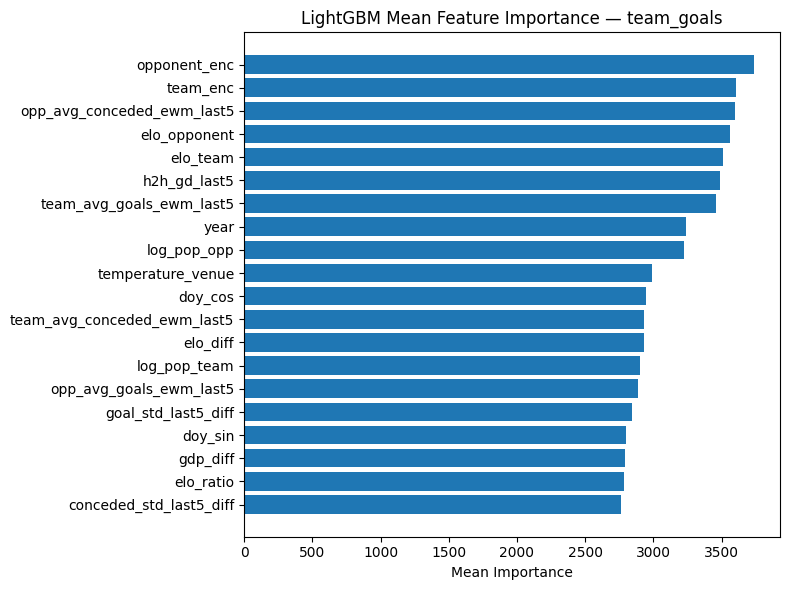

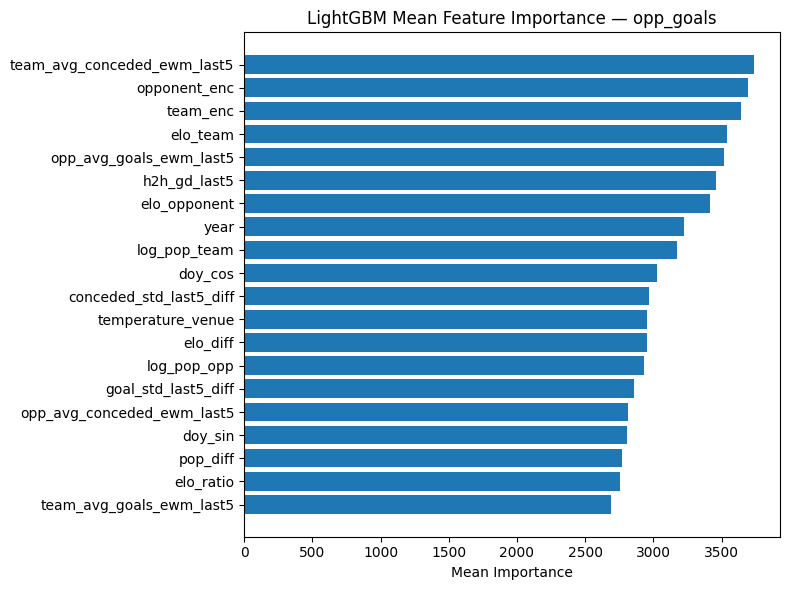

In [104]:
def plot_mean_importance(fi_df, title, topn=20):
    if fi_df is None or len(fi_df) == 0:
        print(f'No feature importance available for {title}')
        return
    
    mean_fi = (
        fi_df.groupby('feature', as_index=False)['importance']
        .mean()
        .sort_values('importance', ascending=False)
        .head(topn)
        .sort_values('importance', ascending=True)
    )

    plt.figure(figsize=(8, 6))
    plt.barh(mean_fi['feature'], mean_fi['importance'])
    plt.title(title)
    plt.xlabel('Mean Importance')
    plt.tight_layout()
    plt.show()

if 'lgb_team' in feature_importance_store:
    plot_mean_importance(feature_importance_store['lgb_team'], 'LightGBM Mean Feature Importance — team_goals')

if 'lgb_opp' in feature_importance_store:
    plot_mean_importance(feature_importance_store['lgb_opp'], 'LightGBM Mean Feature Importance — opp_goals')

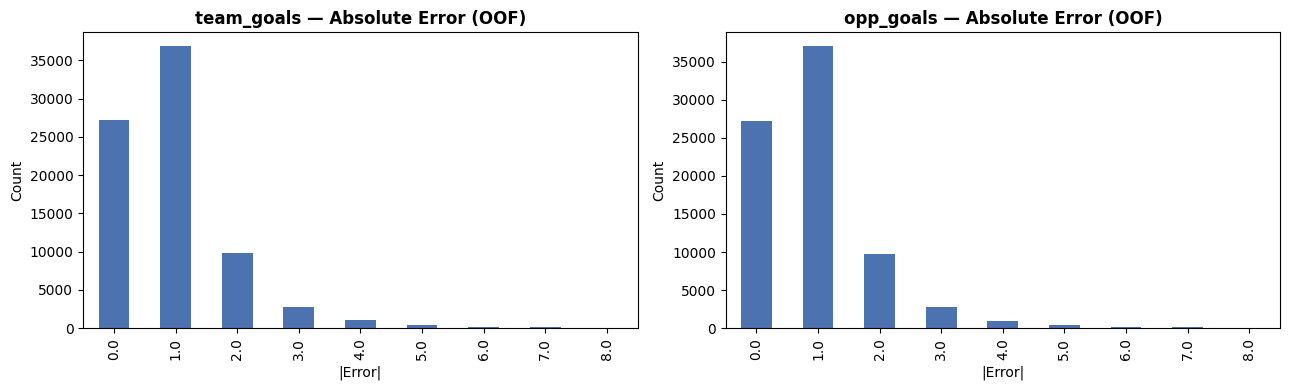

In [105]:
# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, true, pred, lbl in zip(axes, [y_team, y_opp], [tg_r, og_r], ['team_goals', 'opp_goals']):
    errs = np.abs(pred - true)
    pd.Series(errs).value_counts().sort_index()[:8].plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'{lbl} — Absolute Error (OOF)', fontweight='bold')
    ax.set_xlabel('|Error|'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 8. Generate Submission

In [106]:
final_team = np.round(pred_team_final).astype(int).clip(0)
final_opp  = np.round(pred_opp_final).astype(int).clip(0)

submission = pd.DataFrame({
    'Id': test['Id'],
    'team_goals': final_team,
    'opp_goals': final_opp
})

assert list(submission.columns) == list(sub.columns)
assert len(submission) == len(sub)
assert submission[['team_goals', 'opp_goals']].min().min() >= 0

submission.to_csv('submission.csv', index=False)
print(f'✅ submission.csv saved! Shape: {submission.shape}')
print(f'Final source used: {final_source}')
display(submission.head(10))

✅ submission.csv saved! Shape: (42422, 3)
Final source used: lgb


,Id,team_goals,opp_goals
0,M034984_Seychelles,1,2
1,M034984_Mauritius,1,3
2,M034985_Comoros,1,2
3,M034985_Maldives,1,3
4,M034986_Réunion,1,3
5,M034986_Madagascar,1,3
6,M034987_El Salvador,1,4
7,M034987_Venezuela,1,3
8,M034988_Mayotte,2,5
9,M034988_Réunion,2,4


## 9. Summary

In [107]:
print('='*70)
print('  PIPELINE SUMMARY')
print('='*70)
print(f'  Train rows:             {len(train):>10,}')
print(f'  Test rows:              {len(test):>10,}')
print(f'  Features:               {len(FEATURE_COLS):>10}')
print(f'  CV strategy:            {"GroupKFold by match_id":>20}')
print(f'  Models available:       {", ".join(model_outputs.keys()):>20}')
print(f'  Final source:           {final_source:>20}')
print(f'  Sample weight:          {"tournament_weight":>20}')
print('-'*70)
print(f'  OOF AW-MAE:             {score:>10.5f}')
print(f'  Baseline AW-MAE:        {baseline:>10.5f}')
print(f'  Improvement:            {baseline-score:>+10.5f}')
print(f'  Outcome Accuracy:       {outcome_acc:>10.4f}')
print(f'  Exact Score Accuracy:   {exact_acc:>10.4f}')
print(f'  Goal Diff Accuracy:     {gd_acc:>10.4f}')
print('='*70)

  PIPELINE SUMMARY
  Train rows:                 78,772
  Test rows:                  42,422
  Features:                      137
  CV strategy:            GroupKFold by match_id
  Models available:              lgb, xgb, cat
  Final source:                            lgb
  Sample weight:             tournament_weight
----------------------------------------------------------------------
  OOF AW-MAE:                0.91565
  Baseline AW-MAE:           1.35559
  Improvement:              +0.43994
  Outcome Accuracy:           0.5789
  Exact Score Accuracy:       0.1188
  Goal Diff Accuracy:         0.2531
